#  <span style="color:#C133FF"> * (Have) Fun debuggin!* </span> 

In [158]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd
import os
import time

In [3]:
home_path = r"C:\Users\Admin\Documents\msc_project\Image-processing-strategies\chi_opt"
path_to_chi_to_fm_fft = r"C:\Users\Admin\Documents\msc_project\Image-processing-strategies\chi_opt\susceptibility-to-fieldmap-fft"
sys.path.append(path_to_chi_to_fm_fft)
from functions import compute_fieldmap

#  <span style="color:#32B1C7"> Vertebral response of chi lung and trachea  </span>

## Assessing whether lung and tracheal susceptibility effects are distinguishable

To evaluate the sensitivity of the vertebral field profile to each compartment,
the trachea and lungs are simulated separately.

For each compartment, a susceptibility map is created in which the selected ROI
has a susceptibility of `+1 ppm`, while every other voxel is set to zero.

After field simulation, whole-spinal-cord demodulation, and vertebral averaging,
this produces one response vector for the trachea:

$$
\mathbf{t}
=
\begin{bmatrix}
t_{\mathrm{C3}} &
t_{\mathrm{C4}} &
\cdots &
t_{\mathrm{T8}}
\end{bmatrix}^{T}
$$

and one response vector for the lungs:

$$
\mathbf{l}
=
\begin{bmatrix}
l_{\mathrm{C3}} &
l_{\mathrm{C4}} &
\cdots &
l_{\mathrm{T8}}
\end{bmatrix}^{T}
$$

Each element has units of Hz/ppm and describes how much the demodulated mean
field at that vertebral level changes per 1 ppm of susceptibility assigned to
the selected compartment.

Because susceptibility-to-field calculation, demodulation, and regional
averaging are linear operations, these unit-response vectors can be scaled to
predict the effect of any susceptibility value or change.

For example, a change of 0.2 ppm in lung susceptibility produces a vertebral
response of:

$$
\Delta\mathbf{b}_{\mathrm{lung}}
=
0.2\mathbf{l}
$$

These response vectors are used to determine:

1. whether the lung and tracheal response profiles have different shapes;
2. how strongly the vertebral field profile responds to each compartment;
3. whether lung and tracheal susceptibility can be estimated independently.


### Response-matrix analysis

The two response vectors are combined into a sensitivity matrix:

$$
\mathbf{A}
=
\begin{bmatrix}
\mathbf{t} & \mathbf{l}
\end{bmatrix}
=
\begin{bmatrix}
t_{\mathrm{C3}} & l_{\mathrm{C3}} \\
t_{\mathrm{C4}} & l_{\mathrm{C4}} \\
\vdots & \vdots \\
t_{\mathrm{T8}} & l_{\mathrm{T8}}
\end{bmatrix}
$$

Each row represents one vertebral level.

The first column describes the field response to 1 ppm of tracheal
susceptibility, while the second column describes the response to 1 ppm of
lung susceptibility.

For a vector of susceptibility changes:

$$
\Delta\boldsymbol{\chi}
=
\begin{bmatrix}
\Delta\chi_{\mathrm{trachea}} \\
\Delta\chi_{\mathrm{lung}}
\end{bmatrix}
$$

the corresponding change in the vertebral field profile is:

$$
\Delta\mathbf{b}
=
\mathbf{A}\Delta\boldsymbol{\chi}
$$

Several complementary metrics are calculated from this response matrix.


### Pearson correlation

The Pearson correlation measures whether the lung and tracheal responses rise
and fall similarly across vertebral levels.

- A correlation near $+1$ means that the two compartments produce similar
  vertebral response shapes.
- A correlation near $-1$ means that their response shapes are similar but
  have opposite signs.
- A correlation near $0$ indicates little linear similarity between their
  level-dependent patterns.

Correlation compares the variation of each vector around its own mean. It does
not measure the relative magnitude of the two responses.
This correlation is the cosine similarity of the mean-centered response vectors.


### Cosine similarity and angle

Cosine similarity measures the geometric alignment of the complete response
vectors:

$$
\cos(\theta)
=
\frac{
\mathbf{t}^{T}\mathbf{l}
}{
\lVert\mathbf{t}\rVert_2
\lVert\mathbf{l}\rVert_2
}
$$

The angle between the vectors is then calculated as:

$$
\theta
=
\cos^{-1}
\left(
\frac{
\mathbf{t}^{T}\mathbf{l}
}{
\lVert\mathbf{t}\rVert_2
\lVert\mathbf{l}\rVert_2
}
\right)
$$

The interpretation is:

- An angle near $0^\circ$ means the two effects have nearly identical
  directions.
- An angle near $180^\circ$ means they have nearly identical shapes with
  opposite signs.
- An angle near $90^\circ$ means they produce highly distinct response
  patterns.

Unlike Pearson correlation, cosine similarity compares the vectors relative
to zero rather than relative to their individual means.


### Singular values

Singular-value decomposition is applied to the sensitivity matrix
$\mathbf{A}$.

The singular values describe the strength of the independent response
directions contained in the matrix.

If the smaller singular value is close to zero, one response vector can be
reproduced almost completely by scaling the other response vector. In that
case, lung and tracheal susceptibility cannot be estimated independently from
the vertebral measurements.

If both singular values are clearly nonzero, the compartments produce linearly
independent vertebral responses.


### Raw condition number

The raw condition number is the ratio between the largest and smallest
singular values:

$$
\kappa(\mathbf{A})
=
\frac{
\sigma_{\mathrm{max}}
}{
\sigma_{\mathrm{min}}
}
$$

A large raw condition number indicates that estimating the two susceptibility
parameters may be sensitive to measurement noise or modeling errors.

However, the raw condition number is affected by both:

1. similarity between the response shapes;
2. differences between the magnitudes of the responses.

Therefore, the raw condition number may be large because one compartment
produces a much weaker field response, even when the two response shapes are
different.


### Shape-only condition number

To examine response-shape similarity separately from response magnitude, each
column of $\mathbf{A}$ is normalized to have a Euclidean norm of one:

$$
\widetilde{\mathbf{t}}
=
\frac{
\mathbf{t}
}{
\lVert\mathbf{t}\rVert_2
}
$$

$$
\widetilde{\mathbf{l}}
=
\frac{
\mathbf{l}
}{
\lVert\mathbf{l}\rVert_2
}
$$

The normalized sensitivity matrix is:

$$
\widetilde{\mathbf{A}}
=
\begin{bmatrix}
\vert & \vert \\
\widetilde{\mathbf{t}} & \widetilde{\mathbf{l}} \\
\vert & \vert
\end{bmatrix}
$$

The condition number of this normalized matrix is referred to here as the
**shape-only condition number**.

- A value near 1 indicates clearly distinct response directions.
- A large value indicates that the response shapes are nearly redundant.

The term *shape-only condition number* is a descriptive name used in this
analysis rather than a separate standard statistical metric.


### RMS sensitivity

The RMS sensitivity summarizes the typical field change across vertebral
levels caused by a 1 ppm susceptibility change in a compartment:

$$
S_{\mathrm{RMS}}
=
\frac{
\lVert\mathbf{r}\rVert_2
}{
\sqrt{N}
}
$$

Here, $\mathbf{r}$ is the response vector for the selected compartment and
$N$ is the number of vertebral levels.

The units are Hz/ppm.

A larger RMS sensitivity means that the measured vertebral profile is more
sensitive to the susceptibility of that compartment.


## Tracheal response that cannot be explained by the lungs

Even when the tracheal and lung response vectors are not identical, part of the
tracheal response may point in the same direction as the lung response.

This shared component could be reproduced by changing lung susceptibility
instead of tracheal susceptibility.

First, the lung response is normalized:

$$
\widehat{\mathbf{l}}
=
\frac{
\mathbf{l}
}{
\lVert\mathbf{l}\rVert_2
}
$$

The projection of the tracheal response onto the lung direction is:

$$
\mathbf{t}_{\parallel l}
=
\left(
\mathbf{t}^{T}\widehat{\mathbf{l}}
\right)
\widehat{\mathbf{l}}
$$

This is the part of the tracheal response that can be mimicked by adjusting
lung susceptibility.

The projected component is subtracted from the complete tracheal response:

$$
\mathbf{t}_{\perp l}
=
\mathbf{t}
-
\left(
\mathbf{t}^{T}\widehat{\mathbf{l}}
\right)
\widehat{\mathbf{l}}
$$

The remaining vector is orthogonal to the lung response. It represents the
part of the tracheal vertebral pattern that cannot be reproduced by changing
the lung susceptibility alone.

The unique tracheal RMS sensitivity is calculated as:

$$
S_{\mathrm{trachea,unique}}
=
\frac{
\lVert\mathbf{t}_{\perp l}\rVert_2
}{
\sqrt{N}
}
$$

Its units are Hz/ppm.

A small unique tracheal sensitivity means that even a relatively large change
in tracheal susceptibility produces little unique information in the
vertebral profile.

Consequently, the optimizer may determine lung susceptibility relatively well
while leaving tracheal susceptibility weakly constrained.

### Important functions for the notebook

In [157]:
# Define this crucial function for a +1 ppm change in chi in a given ROI, returning a response vector for all vertebral levels inside the vertebral level map
def vertebral_response(
    roi_label,
    roi_data,
    image_res,
    central_freq,
    dmod_mask,
    metric_mask,
    vertebral_levels,
    vertebra_label_map,
):
    """Response to a +1 ppm susceptibility perturbation in one ROI."""

    unit_chi_map = (roi_data == roi_label).astype(float)

    response_hz = (
        compute_fieldmap.compute_bz(
            unit_chi_map,
            image_resolution=image_res,
        )
        * central_freq
    )

    # Use the same demodulation as the optimization
    response_hz -= np.mean(response_hz[dmod_mask == 1])

    return np.array([
        np.mean(
            response_hz[
                metric_mask == vertebra_label_map[level]
            ]
        )
        for level in vertebral_levels
    ])

def extract_demodulated_sc_profile(
    chi_map,
    image_res,
    central_freq,
    dmod_mask,
    metric_mask,
    vertebral_levels,
    vertebra_label_map,
):
    field_hz = (
        compute_fieldmap.compute_bz(
            chi_map,
            image_resolution=image_res,
        )
        * central_freq
    )

    # Subtract the mean field across the complete SC
    sc_mean_hz = np.mean(
        field_hz[dmod_mask == 1]
    )

    demodulated_field_hz = (
        field_hz - sc_mean_hz
    )

    # Extract the mean field at each vertebral level
    sc_profile = np.array([
        np.mean(
            demodulated_field_hz[
                metric_mask
                == vertebra_label_map[level]
            ]
        )
        for level in vertebral_levels
    ])

    return sc_profile

## Import your data and define variables

In [ ]:

# This don't change, this are used with the simulation's FOV for each subject
path_to_sim_metric_mask = r"Z:\neuropoly_data\chi_fitting\chi_018\fm\sim\D2_D3_masks\t1w_wholebody_sc_msk_labeled.nii.gz" # Simulation
path_to_dmod_mask = r"Z:\neuropoly_data\chi_fitting\chi_018\fm\sim\D2_D3_masks\t1w_wholebody_sc_msk.nii.gz" # Simulation
path_to_chimap =  r"Z:\neuropoly_data\chi_fitting\chi_018\fm\sim\B1_chi_maps\chi_018_chi_map_plus_muscle.nii.gz" # This has fixed trachea at 0.27 and skeletal muscle at -9, body is -8.92 - Optimize lungs
path_to_segs = r"R:\soothsayer\msc_data\chi_fitting\chi_018\niftis\t1\segmentations\final_segmentations_plus_muscle.nii.gz"


# In vivo data loading
# load in-vivo average metrics, this covers C3 to T8 (3 to 15)
invivo_avg_metrics = pd.read_csv(r"Z:\neuropoly_data\chi_fitting\chi_018\fm\C_dmod_meas\simple_avg_respiration.csv")
invivo_avg_metrics_values = invivo_avg_metrics['WA()']

gamma_bar = 42.58 # MHz/T
B0 = 3 # [T]

# Get info from json files of the scanner, the central frequency should be the same for both EXP and INSP
central_freq_exp = 123.24935 # in MHz  123.24935 vs 123.248944 (Exp vs Insp)
B0_used_scanner = central_freq_exp /gamma_bar
print("The B0 to use in the simulation should be: ", B0_used_scanner, "T")


# Loading dependencies outside obj. function to decrease computational needs
chi_dist, image_res, affine_matrix = compute_fieldmap.load_sus_dist(path_to_chimap)
sim_chi_img = nib.load(path_to_chimap)
sim_chi_data = sim_chi_img.get_fdata()

# Load segmentation labels that create the chimaps
ROI_img = nib.load(path_to_segs)
ROI_data = ROI_img.get_fdata()

# Find indices with the labels we want to update
ind_trachea = np.where((ROI_data == 113))
ind_lungs = np.where((ROI_data == 12))

dmod_sim_mask = nib.load(path_to_dmod_mask).get_fdata()
metric_sim_mask = nib.load(path_to_sim_metric_mask).get_fdata()

vertebra_label_map = {"C1": 1, "C2": 2, "C3": 3, "C4": 4, "C5": 5, "C6": 6, "C7": 7, "T1": 8, "T2": 9, "T3": 10, "T4": 11, "T5": 12, "T6": 13, "T7": 14, "T8": 15}
vertebrae_levels_opt =  ['C3', 'C4', 'C5', 'C6', 'C7', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8'] # From 3 to 15

trachea_response = vertebral_response(
    roi_label=113,
    roi_data=ROI_data,
    image_res=image_res,
    central_freq=central_freq_exp,
    dmod_mask=dmod_sim_mask,
    metric_mask=metric_sim_mask,
    vertebral_levels=vertebrae_levels_opt,
    vertebra_label_map=vertebra_label_map,
)

lung_response = vertebral_response(
    roi_label=12,
    roi_data=ROI_data,
    image_res=image_res,
    central_freq=central_freq_exp,
    dmod_mask=dmod_sim_mask,
    metric_mask=metric_sim_mask,
    vertebral_levels=vertebrae_levels_opt,
    vertebra_label_map=vertebra_label_map,
)

The B0 to use in the simulation should be:  2.894536167214655 T


In [107]:
label_names = {
    0: "External air",
    5: "Brain",
    7: "Intervertebral disc",
    9: "Skeletal muscle",
    10: "Skull",
    11: "Spine bone",
    12: "Lungs",
    14: "SC",
    113: "Trachea",
    117: "Sinus",
    119: "Ear canal",
    264: "Body",
}

## Create sensitivity matrix, calculate SVD, correlations and RMS for the trachea and lung response vectors!

In [108]:
# Now, to analyze the response
# A is the sensitivity matrix
A = np.column_stack([
    trachea_response,
    lung_response,
])

# Compute SVD
singular_values = np.linalg.svd(A, compute_uv=False)

# We do the cosine similarity
cosine_similarity = (
    np.dot(trachea_response, lung_response)
    / (
        np.linalg.norm(trachea_response)
        * np.linalg.norm(lung_response)
    )
)

# Calculate the angle in degrees between the 2 response vectors
angle_degrees = np.degrees(
    np.arccos(np.clip(cosine_similarity, -1, 1))
)

# Can calculate the correlation 
correlation = np.corrcoef(
    trachea_response,
    lung_response,
)[0, 1] # This 0,1 is to ask for the correlation of trachea vs lung response vectors (same as doing [1,0])

raw_condition_number = (
    singular_values[0] / singular_values[-1]
) # Using the max indexed at 0 and then the smaller SVD is indexed at -1

A_normalized = A / np.linalg.norm(A, axis=0)
normalized_condition_number = np.linalg.cond(A_normalized)

n_levels = len(vertebrae_levels_opt)

print("Trachea response:", trachea_response)
print("Lung response:", lung_response)

print(f"Correlation: {correlation:.3f}")
print(f"Angle: {angle_degrees:.1f} degrees")
print(f"Raw condition number: {raw_condition_number:.2f}")
print(
    "Shape-only condition number: "
    f"{normalized_condition_number:.2f}"
)

print(
    "Trachea RMS sensitivity: "
    f"{np.linalg.norm(trachea_response) / np.sqrt(n_levels):.3f} "
    "Hz/ppm"
)
print(
    "Lung RMS sensitivity: "
    f"{np.linalg.norm(lung_response) / np.sqrt(n_levels):.3f} "
    "Hz/ppm"
)

Trachea response: [-0.14899781 -0.08221977  0.18579686  0.30516241  0.2946651   0.16307932
 -0.04934055 -0.0751151  -0.27585976 -0.3432242  -0.06545429  0.11815995
  0.12780608]
Lung response: [  6.26949597   7.16914178   8.29392403   9.67842697  11.05071579
  10.8197427    3.8881666   -8.05100296 -12.53362529 -11.65947028
 -11.32286152 -13.28051658 -16.13687685]
Correlation: 0.493
Angle: 61.2 degrees
Raw condition number: 60.65
Shape-only condition number: 1.69
Trachea RMS sensitivity: 0.197 Hz/ppm
Lung RMS sensitivity: 10.489 Hz/ppm


In [40]:
vertebral_levels = [
    "C3", "C4", "C5", "C6", "C7",
    "T1", "T2", "T3", "T4", "T5",
    "T6", "T7", "T8",
]

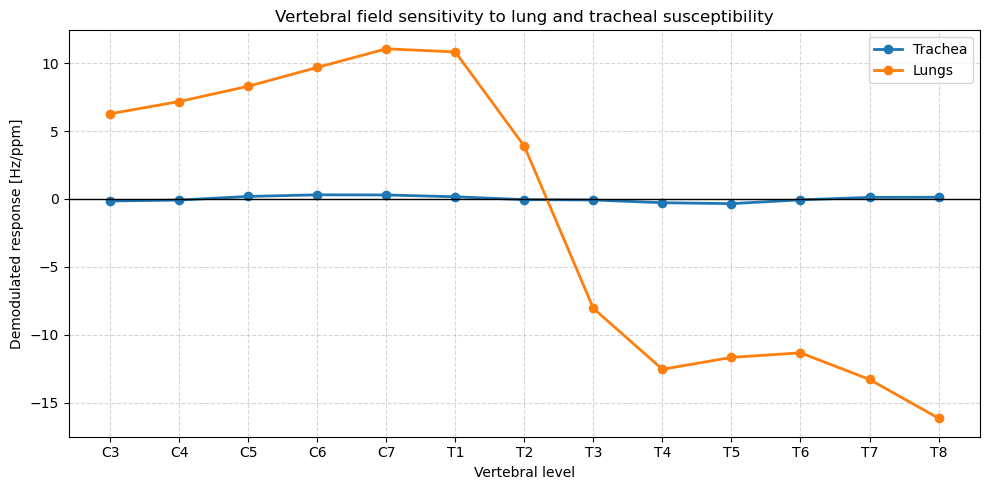

In [109]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    vertebral_levels,
    trachea_response,
    marker="o",
    linewidth=2,
    label="Trachea",
)

ax.plot(
    vertebral_levels,
    lung_response,
    marker="o",
    linewidth=2,
    label="Lungs",
)

ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("Vertebral level")
ax.set_ylabel("Demodulated response [Hz/ppm]")
ax.set_title("Vertebral field sensitivity to lung and tracheal susceptibility")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

fig.tight_layout()
plt.show()

In [110]:
lung_unit = lung_response / np.linalg.norm(lung_response)

trachea_unique = (
    trachea_response
    - np.dot(trachea_response, lung_unit) * lung_unit
)

unique_trachea_rms = (
    np.linalg.norm(trachea_unique)
    / np.sqrt(len(trachea_unique))
)

print(
    "Unique tracheal sensitivity: "
    f"{unique_trachea_rms:.3f} Hz/ppm"
)

Unique tracheal sensitivity: 0.173 Hz/ppm


## How much do all labels affect the SC profile?

In [111]:
all_labels = np.unique(ROI_data)

print("Labels found:", all_labels)
print("Number of labels:", len(all_labels))

Labels found: [  0.   5.   7.   9.  10.  11.  12.  14. 113. 117. 119. 264.]
Number of labels: 12


In [112]:
all_labels = np.unique(ROI_data).astype(int)

In [113]:
response_by_label = {}

for label in all_labels:
    print(f"Calculating response for label {label}...")

    response_by_label[int(label)] = vertebral_response(
        roi_label=label,
        roi_data=ROI_data,
        image_res=image_res,
        central_freq=central_freq_exp,
        dmod_mask=dmod_sim_mask,
        metric_mask=metric_sim_mask,
        vertebral_levels=vertebrae_levels_opt,
        vertebra_label_map=vertebra_label_map,
    )

Calculating response for label 0...
Calculating response for label 5...
Calculating response for label 7...
Calculating response for label 9...
Calculating response for label 10...
Calculating response for label 11...
Calculating response for label 12...
Calculating response for label 14...
Calculating response for label 113...
Calculating response for label 117...
Calculating response for label 119...
Calculating response for label 264...


In [114]:
response_df = pd.DataFrame(
    response_by_label,
    index=vertebrae_levels_opt,
).T

response_df.index.name = "Label"
response_df.columns.name = "Vertebral level"

response_df

Vertebral level,C3,C4,C5,C6,C7,T1,T2,T3,T4,T5,T6,T7,T8
Label,,,,,,,,,,,,,
0,-28.648219,-30.028841,-28.471362,-24.006853,-17.398736,-8.778410,-0.023998,6.695243,11.083311,13.995916,16.823478,19.586732,21.774011
5,4.091205,-0.098454,-2.334388,-3.771094,-4.741446,-5.494403,-6.046473,-6.413555,-6.648813,-6.784163,-6.857661,-6.883487,-6.865162
7,-0.737077,-0.359553,-0.172601,-0.250638,-0.167479,0.007094,0.441876,0.007044,-0.254766,-0.229566,-0.155931,-0.300660,-0.446047
9,2.328389,-6.092161,-8.263618,-6.455220,-4.416092,-4.189247,-1.793104,-1.238187,0.025263,2.201390,4.328825,5.429215,5.628986
10,2.735219,1.793253,1.112229,0.615385,0.252642,-0.042719,-0.264809,-0.414567,-0.511239,-0.567276,-0.598591,-0.611443,-0.608012
11,-1.385614,1.169947,2.749279,2.852977,1.394874,-0.481213,0.712513,1.662967,2.867023,2.173560,-0.061896,0.195656,-0.800528
12,6.269496,7.169142,8.293924,9.678427,11.050716,10.819743,3.888167,-8.051003,-12.533625,-11.659470,-11.322862,-13.280517,-16.136877
14,3.356466,3.074225,1.138135,0.143314,-1.887789,-4.290146,-5.755452,-3.499605,-2.206448,-0.436171,2.476414,2.818841,3.711906
113,-0.148998,-0.082220,0.185797,0.305162,0.294665,0.163079,-0.049341,-0.075115,-0.275860,-0.343224,-0.065454,0.118160,0.127806


In [115]:
response_df_named = response_df.copy()

response_df_named.index = [
    label_names.get(label, f"Label {label}")
    for label in response_df.index
]

response_df_named

Vertebral level,C3,C4,C5,C6,C7,T1,T2,T3,T4,T5,T6,T7,T8
External air,-28.648219,-30.028841,-28.471362,-24.006853,-17.398736,-8.778410,-0.023998,6.695243,11.083311,13.995916,16.823478,19.586732,21.774011
Brain,4.091205,-0.098454,-2.334388,-3.771094,-4.741446,-5.494403,-6.046473,-6.413555,-6.648813,-6.784163,-6.857661,-6.883487,-6.865162
Intervertebral disc,-0.737077,-0.359553,-0.172601,-0.250638,-0.167479,0.007094,0.441876,0.007044,-0.254766,-0.229566,-0.155931,-0.300660,-0.446047
Skeletal muscle,2.328389,-6.092161,-8.263618,-6.455220,-4.416092,-4.189247,-1.793104,-1.238187,0.025263,2.201390,4.328825,5.429215,5.628986
Skull,2.735219,1.793253,1.112229,0.615385,0.252642,-0.042719,-0.264809,-0.414567,-0.511239,-0.567276,-0.598591,-0.611443,-0.608012
Spine bone,-1.385614,1.169947,2.749279,2.852977,1.394874,-0.481213,0.712513,1.662967,2.867023,2.173560,-0.061896,0.195656,-0.800528
Lungs,6.269496,7.169142,8.293924,9.678427,11.050716,10.819743,3.888167,-8.051003,-12.533625,-11.659470,-11.322862,-13.280517,-16.136877
SC,3.356466,3.074225,1.138135,0.143314,-1.887789,-4.290146,-5.755452,-3.499605,-2.206448,-0.436171,2.476414,2.818841,3.711906
Trachea,-0.148998,-0.082220,0.185797,0.305162,0.294665,0.163079,-0.049341,-0.075115,-0.275860,-0.343224,-0.065454,0.118160,0.127806
Sinus,0.074130,0.086651,0.073228,0.057069,0.041719,0.028004,0.017638,0.010945,0.006935,0.004814,0.003654,0.003043,0.002755


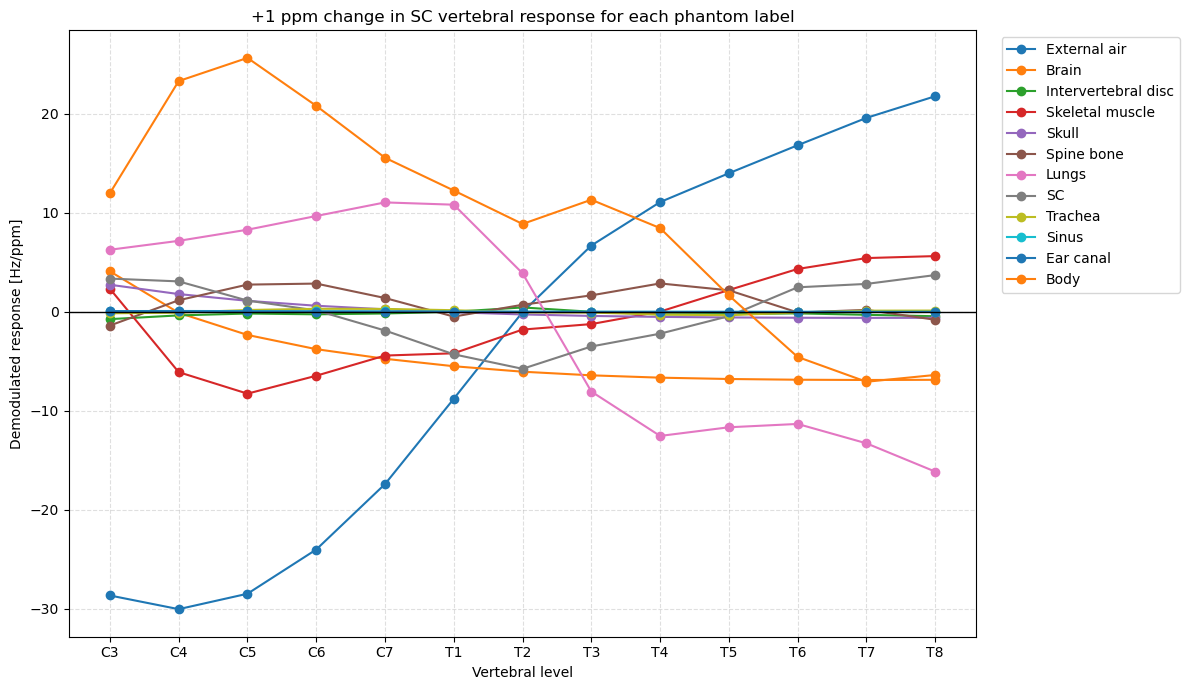

In [116]:
fig, ax = plt.subplots(figsize=(12, 7))

for label_name, response in response_df_named.iterrows():
    ax.plot(
        vertebrae_levels_opt,
        response.values,
        marker="o",
        linewidth=1.5,
        label=label_name,
    )

ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("Vertebral level")
ax.set_ylabel("Demodulated response [Hz/ppm]")
ax.set_title("+1 ppm change in SC vertebral response for each phantom label")
ax.grid(True, linestyle="--", alpha=0.4)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()
plt.show()

In [117]:
actual_contribution_by_label = {}

for label, response in response_by_label.items():
    label_mask = (ROI_data == label)

    chi_value = np.mean(
        sim_chi_data[label_mask]
    )

    actual_contribution_by_label[label] = (
        chi_value * response
    )

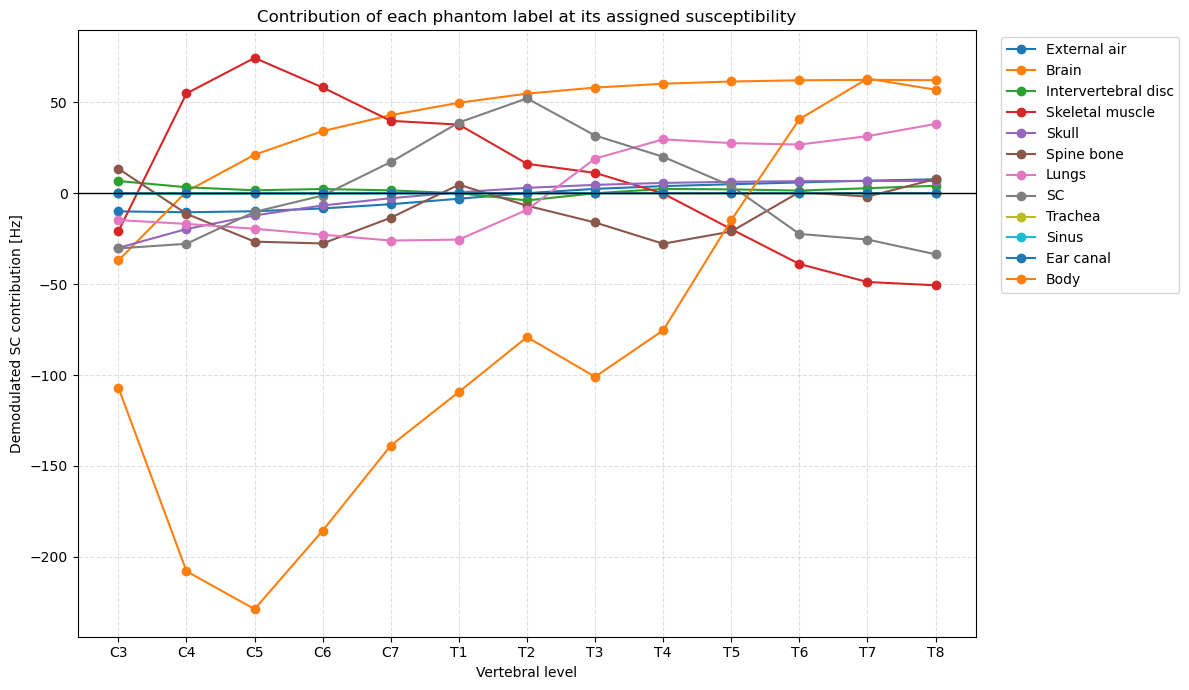

In [118]:
fig, ax = plt.subplots(figsize=(12, 7))

for label, contribution in actual_contribution_by_label.items():
    label_name = label_names.get(
        label,
        f"Label {label}",
    )

    ax.plot(
        vertebrae_levels_opt,
        contribution,
        marker="o",
        linewidth=1.5,
        label=f"{label_name}",
    )

ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("Vertebral level")
ax.set_ylabel("Demodulated SC contribution [Hz]")
ax.set_title(
    "Contribution of each phantom label "
    "at its assigned susceptibility"
)

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()
plt.show()

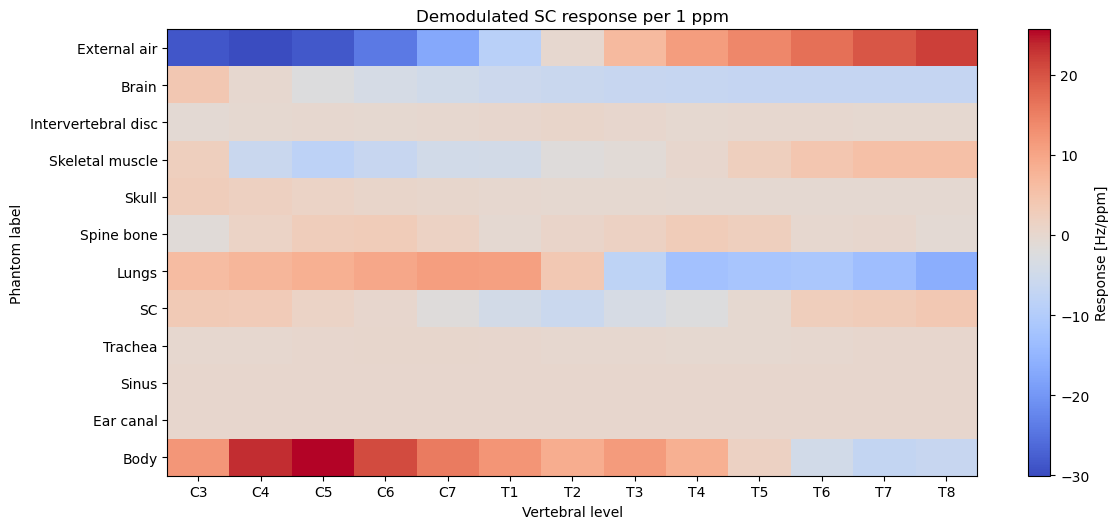

In [119]:
fig, ax = plt.subplots(
    figsize=(12, max(5, 0.45 * len(response_df_named)))
)

image = ax.imshow(
    response_df_named.values,
    aspect="auto",
    cmap="coolwarm",
)

ax.set_xticks(np.arange(len(vertebrae_levels_opt)))
ax.set_xticklabels(vertebrae_levels_opt)

ax.set_yticks(np.arange(len(response_df_named)))
ax.set_yticklabels(response_df_named.index)

ax.set_xlabel("Vertebral level")
ax.set_ylabel("Phantom label")
ax.set_title("Demodulated SC response per 1 ppm")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Response [Hz/ppm]")

fig.tight_layout()
plt.show()

In [120]:
rms_sensitivity = (
    np.linalg.norm(response_df_named.values, axis=1)
    / np.sqrt(len(vertebrae_levels_opt))
)

sensitivity_df = pd.DataFrame({
    "Label": response_df_named.index,
    "RMS sensitivity [Hz/ppm]": rms_sensitivity,
})

sensitivity_df = sensitivity_df.sort_values(
    "RMS sensitivity [Hz/ppm]",
    ascending=False,
)

sensitivity_df

,Label,RMS sensitivity [Hz/ppm]
0,External air,19.598872
11,Body,14.038264
6,Lungs,10.489185
1,Brain,5.536962
3,Skeletal muscle,4.632995
7,SC,3.067065
5,Spine bone,1.711145
4,Skull,1.049014
2,Intervertebral disc,0.330483
8,Trachea,0.197404


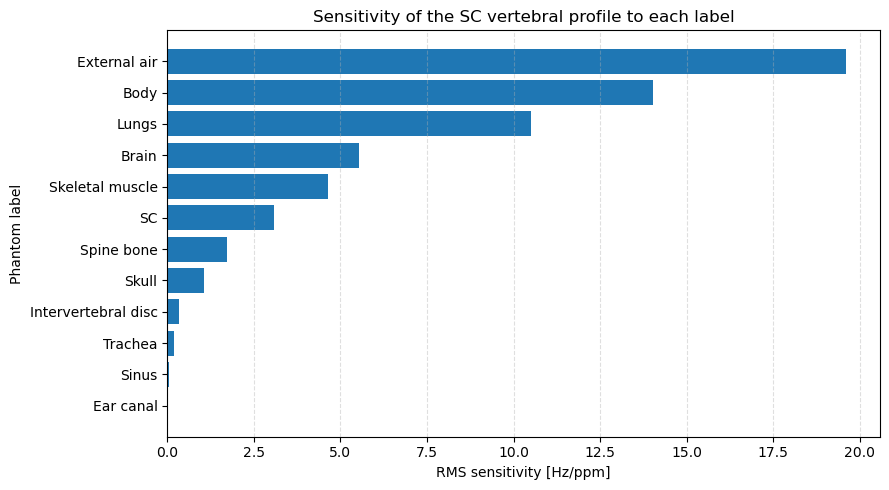

In [121]:
fig, ax = plt.subplots(
    figsize=(9, max(5, 0.4 * len(sensitivity_df)))
)

ax.barh(
    sensitivity_df["Label"],
    sensitivity_df["RMS sensitivity [Hz/ppm]"],
)

ax.invert_yaxis()

ax.set_xlabel("RMS sensitivity [Hz/ppm]")
ax.set_ylabel("Phantom label")
ax.set_title("Sensitivity of the SC vertebral profile to each label")
ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

## Testing dilation of trachea label by 3 voxels in plane

In [138]:
trachea_dilated3_seg_data = nib.load(r"R:\soothsayer\msc_data\chi_fitting\chi_018\niftis\t1\segmentations\final_segmentations_plus_muscle_trachea_dilate3.nii.gz").get_fdata()
trachea_dilated3_chimap_img = nib.load(r"Z:\neuropoly_data\chi_fitting\chi_018\fm\sim\B1_chi_maps\chi_018_chi_map_plus_muscle_trachea_dilate3.nii.gz")
trachea_dilated3_chimap_data = trachea_dilated3_chimap_img.get_fdata()

In [140]:
original_trachea = (ROI_data == 113)

dilated3_trachea = (
    trachea_dilated3_seg_data == 113
)

original_slices = np.where(
    np.any(original_trachea, axis=(0, 1))
)[0]

dilated3_slices = np.where(
    np.any(dilated3_trachea, axis=(0, 1))
)[0]

print(
    "Original trachea slice range:",
    original_slices.min(),
    "to",
    original_slices.max(),
)

print(
    "Dilated trachea slice range:",
    dilated3_slices.min(),
    "to",
    dilated3_slices.max(),
)

print(
    "Original trachea voxels:",
    np.count_nonzero(original_trachea),
)

print(
    "Dilated trachea voxels:",
    np.count_nonzero(dilated3_trachea),
)

Original trachea slice range: 174 to 449
Dilated trachea slice range: 174 to 449
Original trachea voxels: 23305
Dilated trachea voxels: 57438


In [142]:
dilated3_profile = extract_demodulated_sc_profile(
    chi_map=trachea_dilated3_chimap_data,
    image_res=image_res,
    central_freq=central_freq_exp,
    dmod_mask=dmod_sim_mask,
    metric_mask=metric_sim_mask,
    vertebral_levels=vertebrae_levels_opt,
    vertebra_label_map=vertebra_label_map,
)

In [143]:
original_profile = extract_demodulated_sc_profile(
    chi_map=sim_chi_data,
    image_res=image_res,
    central_freq=central_freq_exp,
    dmod_mask=dmod_sim_mask,
    metric_mask=metric_sim_mask,
    vertebral_levels=vertebrae_levels_opt,
    vertebra_label_map=vertebra_label_map,
)

In [144]:
dilated3_profile_change = (
    dilated3_profile
    - original_profile
)

dilated3_rmse = np.sqrt(
    np.mean(dilated3_profile_change**2)
)

print(
    "Profile-change RMSE:",
    f"{dilated3_rmse:.4f} Hz",
)

print(
    "Maximum absolute change:",
    f"{np.max(np.abs(dilated3_profile_change)):.4f} Hz",
)

Profile-change RMSE: 2.7801 Hz
Maximum absolute change: 6.3141 Hz


In [145]:
trachea_dilated3_response = vertebral_response(
    roi_label=113,
    roi_data=trachea_dilated3_seg_data,
    image_res=image_res,
    central_freq=central_freq_exp,
    dmod_mask=dmod_sim_mask,
    metric_mask=metric_sim_mask,
    vertebral_levels=vertebrae_levels_opt,
    vertebra_label_map=vertebra_label_map,
)

In [146]:
trachea_response_difference = (
    trachea_dilated3_response
    - trachea_response
)

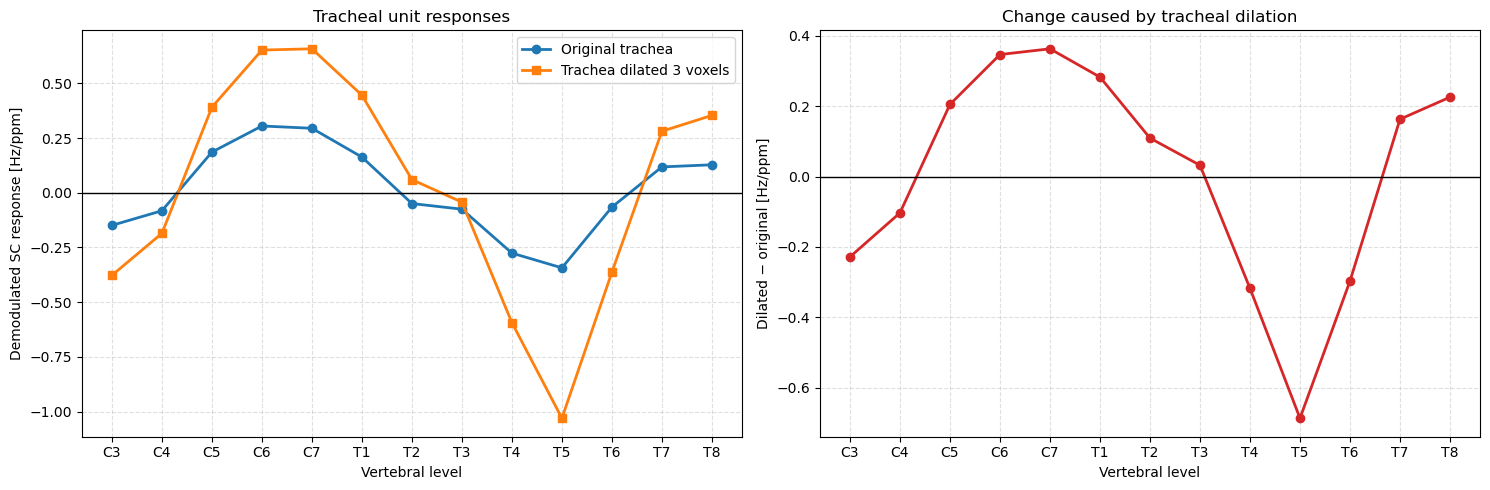

In [147]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

# Original and dilated unit-response curves
axes[0].plot(
    vertebrae_levels_opt,
    trachea_response,
    marker="o",
    linewidth=2,
    label="Original trachea",
)

axes[0].plot(
    vertebrae_levels_opt,
    trachea_dilated3_response,
    marker="s",
    linewidth=2,
    label="Trachea dilated 3 voxels",
)

axes[0].axhline(
    0,
    color="black",
    linewidth=1,
)

axes[0].set_xlabel("Vertebral level")
axes[0].set_ylabel(
    "Demodulated SC response [Hz/ppm]"
)
axes[0].set_title(
    "Tracheal unit responses"
)
axes[0].grid(
    True,
    linestyle="--",
    alpha=0.4,
)
axes[0].legend()


# Difference between unit responses
axes[1].plot(
    vertebrae_levels_opt,
    trachea_response_difference,
    marker="o",
    linewidth=2,
    color="tab:red",
)

axes[1].axhline(
    0,
    color="black",
    linewidth=1,
)

axes[1].set_xlabel("Vertebral level")
axes[1].set_ylabel(
    "Dilated − original [Hz/ppm]"
)
axes[1].set_title(
    "Change caused by tracheal dilation"
)
axes[1].grid(
    True,
    linestyle="--",
    alpha=0.4,
)

fig.tight_layout()
plt.show()

## New optimization approach! </br>
After all the above we can conclude that chi-trachea actually impacts in a very small magnitude and a optimizer like NOMAD may not be ideal because of how large the trachea lung changes overlap with chi trachea changes.
For this reason let's test by fixing the trachea label to 0.26 ppm - from manual calculations.
Also, I know believe that the optimization of chi-lung should be unconstrained. The variations in the field come mainly from the many small air-tissue boundaries in the alveoli. 
We are not segmenting the alveoli and its therefore erroneous to assume that the upper bound would be chi-air and the lowest bound would be chi-bone. 
This would rephrase the project to be chi-effective for a homogenoeus lung susceptibility distribution!

In [ ]:
lung_label = 12
trachea_label = 113

chi_trachea_fixed = 0.26

fixed_chi_map = sim_chi_data.copy()

# Here now, we remove the lung label
fixed_chi_map[ROI_data == lung_label] = 0.0
fixed_chi_map[ROI_data == trachea_label] = (
    chi_trachea_fixed
)

In [ ]:
# Because the lung label is removed, we can now extract the demodulate SC profile without the lungs contribution and added after using chi_lung * lung_response !!
fixed_profile = extract_demodulated_sc_profile(
    chi_map=fixed_chi_map,
    image_res=image_res,
    central_freq=central_freq_exp,
    dmod_mask=dmod_sim_mask,
    metric_mask=metric_sim_mask,
    vertebral_levels=vertebrae_levels_opt,
    vertebra_label_map=vertebra_label_map,
)

In [ ]:
# This is the participants measured profile!
measured_profile = np.asarray(
    invivo_avg_metrics_values,
    dtype=float,
)

In [ ]:
# This tells us how much the the chi lung response needs to be to match the measured profile
target_for_lung = (
    measured_profile
    - fixed_profile
)

In [ ]:
# Unconstrained analytical solution
chi_lung_unconstrained = (
    np.dot(
        lung_response,
        measured_profile - fixed_profile,
    )
    / np.dot(
        lung_response,
        lung_response,
    )
)

print(
    "Unconstrained lung susceptibility:",
    f"{chi_lung_unconstrained:.4f} ppm",
)

Unconstrained lung susceptibility: 4.6722 ppm
Constrained lung susceptibility: 0.2000 ppm


In [ ]:
profile_unconstrained = (
    fixed_profile
    + chi_lung_unconstrained * lung_response
)

In [ ]:
residual_unconstrained = (
    profile_unconstrained
    - measured_profile
)

rmse_unconstrained = np.sqrt(
    np.mean(residual_unconstrained**2)
)



print(
    "Unconstrained RMSE:",
    f"{rmse_unconstrained:.4f} Hz",
)


Unconstrained RMSE: 59.0555 Hz
Constrained RMSE: 75.4196 Hz


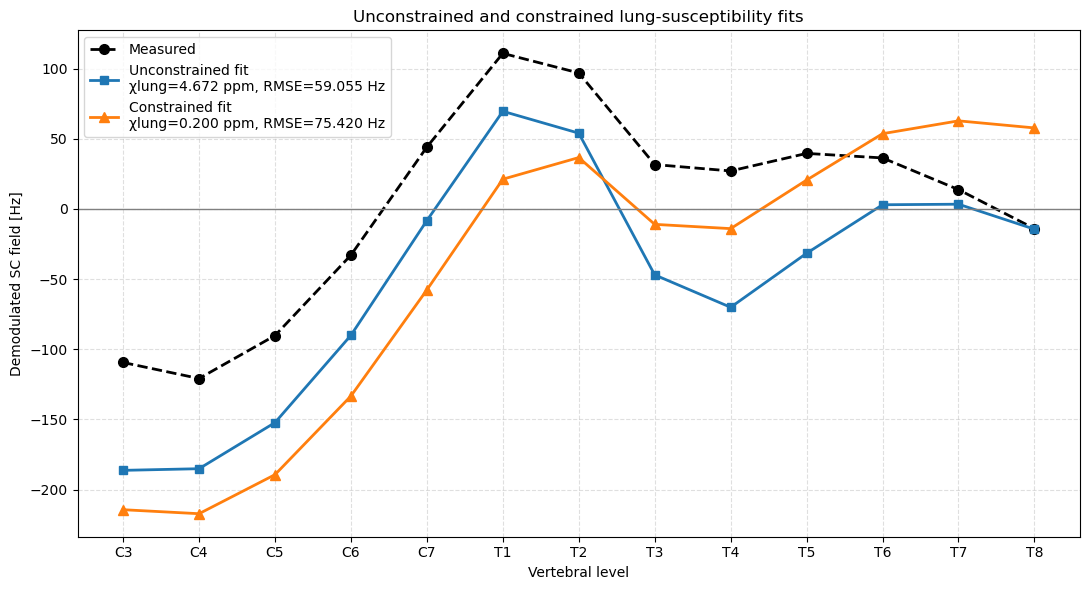

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    vertebrae_levels_opt,
    measured_profile,
    marker="o",
    markersize=7,
    linestyle="--",
    linewidth=2,
    color="black",
    label="Measured",
)

ax.plot(
    vertebrae_levels_opt,
    profile_unconstrained,
    marker="s",
    markersize=6,
    linewidth=2,
    color="tab:blue",
    label=(
        "Unconstrained fit\n"
        f"χlung={chi_lung_unconstrained:.3f} ppm, "
        f"RMSE={rmse_unconstrained:.3f} Hz"
    ),
)


ax.axhline(
    0,
    color="gray",
    linewidth=1,
)

ax.set_xlabel("Vertebral level")
ax.set_ylabel("Demodulated SC field [Hz]")

ax.set_title(
    "Unconstrained and constrained "
    "lung-susceptibility fits"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4,
)

ax.legend()

fig.tight_layout()
plt.show()